# Laboratorio de IA ética: Titanic

Modelo base y transformación de variables. Aprendemos las reglas con entrenamiento y evaluamos sobre validación.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/memo124/Laboratorio_IA_etica/blob/main/main.ipynb)

## 1. Dependencias

Ejecuta las celdas en orden en Colab.

In [1]:
%pip install -q optuna plotly "scikit-learn>=1.3"

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import optuna
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder

/tmp/titanic-final-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carga y exploración

Cada fila es un pasajero. `Survived` indica supervivencia (1) o fallecimiento (0). Leemos el CSV local o lo descargamos.

In [3]:
DATA_PATH = Path("train.csv")
DATA_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

if DATA_PATH.exists():
    data = pd.read_csv(DATA_PATH)
else:
    data = pd.read_csv(DATA_URL)
    # Guardamos una copia para no descargarla otra vez en esta sesión.
    data.to_csv(DATA_PATH, index=False)

Revisamos las primeras filas, los tipos de datos y la cantidad de valores faltantes.

In [4]:
display(data.head())

data.info()

display(data.isna().sum())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 3. División de datos

Dividimos en entrenamiento (60 %), validación (20 %) y prueba (20 %). `stratify` conserva la proporción de supervivientes; la semilla 42 permite repetir la división.

In [5]:
features = data.drop(columns=["Survived"])
target = data["Survived"]

X_remaining, X_test, y_remaining, y_test = train_test_split(
    features,
    target,
    test_size=0.20,
    stratify=target,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_remaining,
    y_remaining,
    test_size=0.25,
    stratify=y_remaining,
    random_state=42,
)

print("Pasajeros de entrenamiento:", len(X_train))
print("Pasajeros de validación:", len(X_val))
print("Pasajeros de prueba:", len(X_test))

Pasajeros de entrenamiento: 534
Pasajeros de validación: 178
Pasajeros de prueba: 179


## 4. Preprocesamiento

Completamos números con la mediana y categorías con el valor más frecuente. One-hot crea columnas de ceros y unos. `Pclass` se trata como categoría.

In [6]:
numeric_columns = ["Age", "SibSp", "Parch", "Fare"]
categorical_columns = ["Pclass", "Sex", "Embarked"]

numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_columns),
        ("categorical", categorical_transformer, categorical_columns),
    ],
    verbose_feature_names_out=False,
)

## 5. Modelo base y entrenamiento

El pipeline prepara los datos y entrena un Random Forest de 100 árboles, usando solo entrenamiento.

In [7]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42)

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", classifier),
])

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['PassengerId','Pclass','Name',...,'Fare','Cabin','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to set

## 6. Preparación de validación y prueba

`transform` aplica las reglas aprendidas sin reajustarlas. Prueba queda reservada para la evaluación final.

In [8]:
fitted_preprocessor = baseline_model.named_steps["preprocessor"]
X_val_prepared = fitted_preprocessor.transform(X_val)
X_test_prepared = fitted_preprocessor.transform(X_test)

# shape muestra la cantidad de filas y columnas resultantes.
print("Validación preparada:", X_val_prepared.shape)
print("Prueba preparada:", X_test_prepared.shape)

Validación preparada: (178, 12)
Prueba preparada: (179, 12)


## 7. Evaluación del Baseline

Calculamos F1 en validación como referencia. Combina precisión y sensibilidad: cuanto más cerca de 1, mejor.

In [9]:
y_val_pred = baseline_model.predict(X_val)
validation_f1 = f1_score(y_val, y_val_pred)

print(f"F1 del Baseline en validación: {validation_f1:.4f}")

print(classification_report(y_val, y_val_pred))

F1 del Baseline en validación: 0.7704
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       110
           1       0.78      0.76      0.77        68

    accuracy                           0.83       178
   macro avg       0.82      0.81      0.82       178
weighted avg       0.83      0.83      0.83       178



## 8. Distribución del precio del boleto

El histograma agrupa los precios en 30 intervalos. Observamos si predominan precios bajos con una cola hacia valores altos.

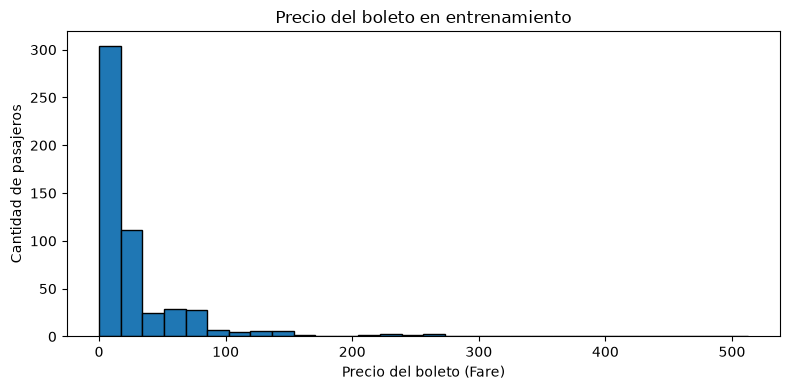

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(X_train["Fare"].dropna(), bins=30, edgecolor="black")
plt.title("Precio del boleto en entrenamiento")
plt.xlabel("Precio del boleto (Fare)")
plt.ylabel("Cantidad de pasajeros")
plt.tight_layout()
plt.show()

## 9. Copias y valores faltantes

Creamos copias y completamos faltantes con las medianas de entrenamiento. Las columnas originales se conservan.

In [11]:
X_train_engineered = X_train.copy()
X_val_engineered = X_val.copy()
X_test_engineered = X_test.copy()

fare_median = X_train["Fare"].median()
age_median = X_train["Age"].median()

In [12]:
fare_train_filled = X_train["Fare"].fillna(fare_median)
fare_val_filled = X_val["Fare"].fillna(fare_median)
fare_test_filled = X_test["Fare"].fillna(fare_median)

age_train_filled = X_train["Age"].fillna(age_median)
age_val_filled = X_val["Age"].fillna(age_median)
age_test_filled = X_test["Age"].fillna(age_median)

## 10. Transformación logarítmica

`np.log1p` comprime los precios altos y admite ceros. Guardamos el resultado en `Fare_log` sin reemplazar `Fare`.

In [13]:
X_train_engineered["Fare_log"] = np.log1p(fare_train_filled)
X_val_engineered["Fare_log"] = np.log1p(fare_val_filled)
X_test_engineered["Fare_log"] = np.log1p(fare_test_filled)

## 11. Histogramas antes y después

Comparamos entrenamiento antes y después del logaritmo. Los ejes horizontales tienen distintas unidades.

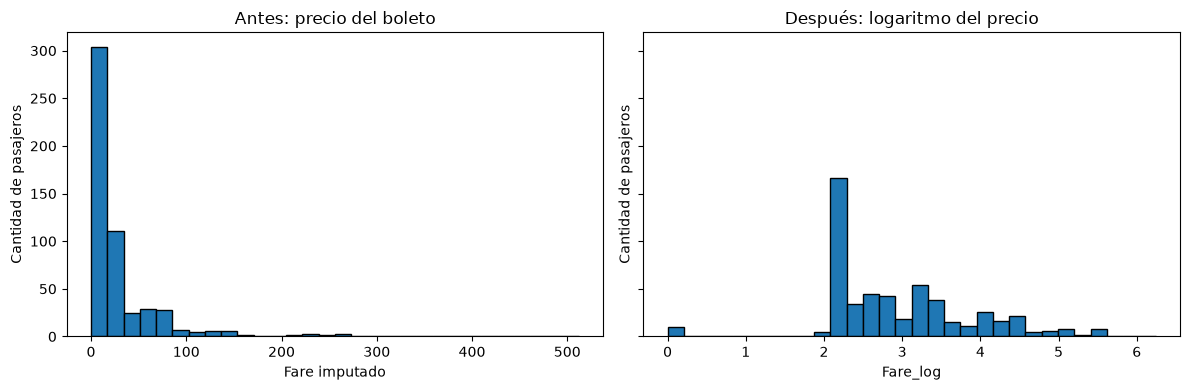

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(fare_train_filled, bins=30, edgecolor="black")
axes[0].set_title("Antes: precio del boleto")
axes[0].set_xlabel("Fare imputado")
axes[0].set_ylabel("Cantidad de pasajeros")

axes[1].hist(X_train_engineered["Fare_log"], bins=30, edgecolor="black")
axes[1].set_title("Después: logaritmo del precio")
axes[1].set_xlabel("Fare_log")
axes[1].set_ylabel("Cantidad de pasajeros")

plt.tight_layout()
plt.show()

El logaritmo comprime la cola de precios altos; esto no garantiza mejores predicciones.

## 12. Revisión de valores extremos

El boxplot muestra la mediana, la dispersión y posibles extremos. Un valor extremo no necesariamente es un error.

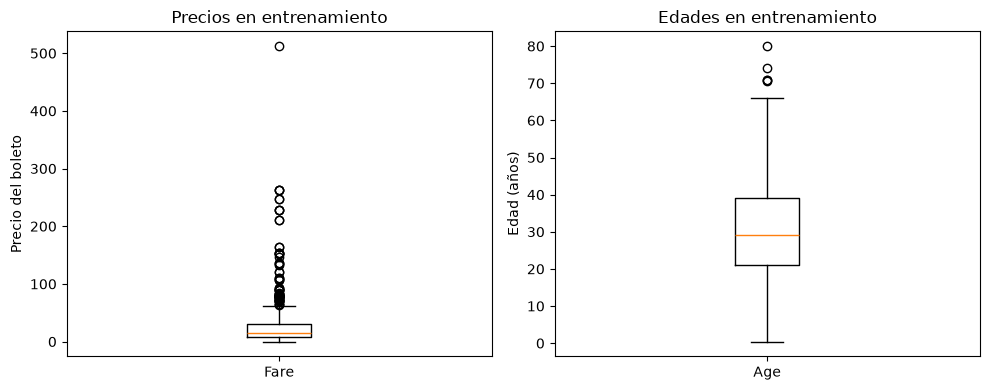

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot(X_train["Fare"].dropna())
axes[0].set_title("Precios en entrenamiento")
axes[0].set_xticks([1], ["Fare"])
axes[0].set_ylabel("Precio del boleto")

axes[1].boxplot(X_train["Age"].dropna())
axes[1].set_title("Edades en entrenamiento")
axes[1].set_xticks([1], ["Age"])
axes[1].set_ylabel("Edad (años)")

plt.tight_layout()
plt.show()

## 13. Límites para recortar extremos

Calculamos los percentiles 1 y 99 solo con entrenamiento, ignorando faltantes. Aproximadamente el 1 % queda por debajo del primer límite y el 1 % por encima del segundo.

In [16]:
fare_lower = X_train["Fare"].quantile(0.01)
fare_upper = X_train["Fare"].quantile(0.99)
age_lower = X_train["Age"].quantile(0.01)
age_upper = X_train["Age"].quantile(0.99)

winsor_limits = pd.DataFrame({
    "Variable": ["Fare", "Age"],
    "Percentil 1": [fare_lower, age_lower],
    "Percentil 99": [fare_upper, age_upper],
})
display(winsor_limits)

,Variable,Percentil 1,Percentil 99
0,Fare,0.000,240.922186
1,Age,0.948,68.925000


## 14. Winsorización del precio y la edad

Winsorizar recorta extremos sin eliminar filas. Aplicamos `clip` con los mismos límites de entrenamiento a las tres particiones.

In [17]:
X_train_engineered["Fare_winsor"] = fare_train_filled.clip(lower=fare_lower, upper=fare_upper)
X_val_engineered["Fare_winsor"] = fare_val_filled.clip(lower=fare_lower, upper=fare_upper)
X_test_engineered["Fare_winsor"] = fare_test_filled.clip(lower=fare_lower, upper=fare_upper)

In [18]:
X_train_engineered["Age_winsor"] = age_train_filled.clip(lower=age_lower, upper=age_upper)
X_val_engineered["Age_winsor"] = age_val_filled.clip(lower=age_lower, upper=age_upper)
X_test_engineered["Age_winsor"] = age_test_filled.clip(lower=age_lower, upper=age_upper)

## 15. Boxplots antes y después

Comparamos los valores imputados antes y después del recorte, con la misma escala por variable.

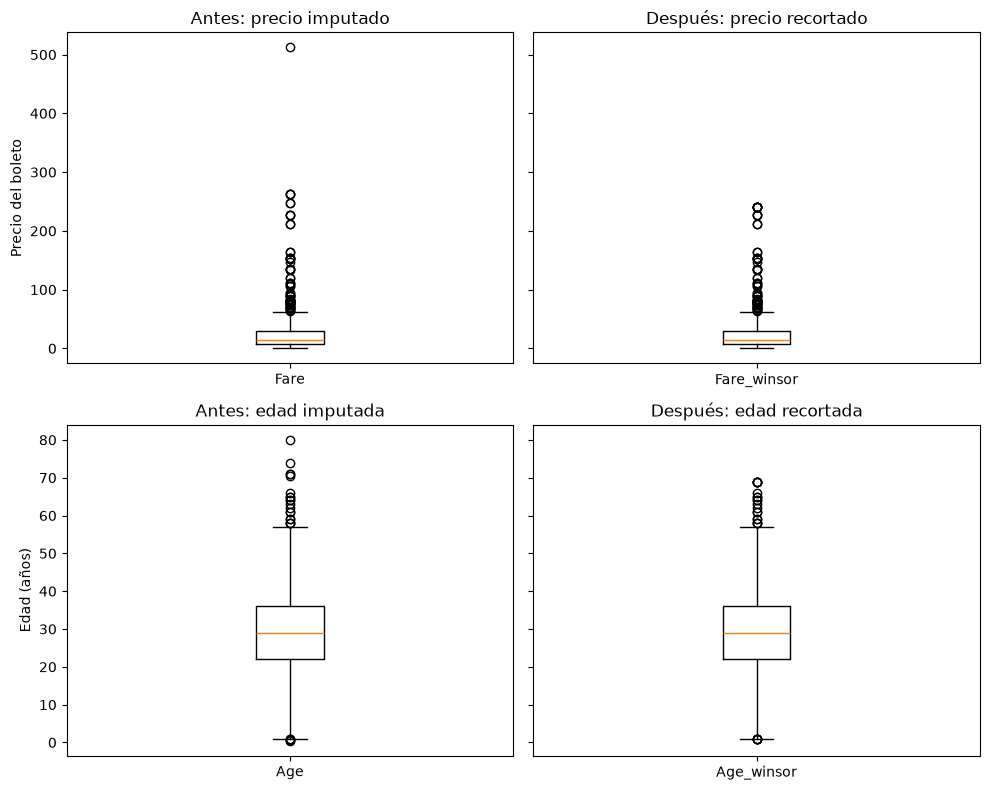

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey="row")

axes[0, 0].boxplot(fare_train_filled)
axes[0, 0].set_title("Antes: precio imputado")
axes[0, 0].set_xticks([1], ["Fare"])
axes[0, 0].set_ylabel("Precio del boleto")

axes[0, 1].boxplot(X_train_engineered["Fare_winsor"])
axes[0, 1].set_title("Después: precio recortado")
axes[0, 1].set_xticks([1], ["Fare_winsor"])

axes[1, 0].boxplot(age_train_filled)
axes[1, 0].set_title("Antes: edad imputada")
axes[1, 0].set_xticks([1], ["Age"])
axes[1, 0].set_ylabel("Edad (años)")

axes[1, 1].boxplot(X_train_engineered["Age_winsor"])
axes[1, 1].set_title("Después: edad recortada")
axes[1, 1].set_xticks([1], ["Age_winsor"])

plt.tight_layout()
plt.show()

El recorte conserva todos los pasajeros. Pueden quedar puntos fuera de los bigotes porque el boxplot usa un criterio distinto de los percentiles.

## 16. Preparación de Ticket

Completamos boletos faltantes con `Desconocido` y los tratamos como texto. Contamos los boletos distintos y mostramos los más frecuentes en entrenamiento.

In [20]:
ticket_train = X_train[["Ticket"]].fillna("Desconocido").astype(str)
ticket_val = X_val[["Ticket"]].fillna("Desconocido").astype(str)
ticket_test = X_test[["Ticket"]].fillna("Desconocido").astype(str)

print("Boletos distintos:", ticket_train["Ticket"].nunique())
display(ticket_train["Ticket"].value_counts().head())

Boletos distintos: 448


Ticket
347088      4
3101295     4
CA 2144     4
347077      4
CA. 2343    4
Name: count, dtype: int64

## 17. Target Encoding

Convertimos cada boleto en un número aprendido de las respuestas de entrenamiento. `fit_transform` usa divisiones internas para evitar usar directamente la respuesta de la misma fila; en validación y prueba usamos solo `transform`.

In [21]:
ticket_encoder = TargetEncoder(target_type="binary", random_state=42)

# ravel convierte la matriz de una columna en valores para asignar a la tabla.
X_train_engineered["Ticket_encoded"] = ticket_encoder.fit_transform(ticket_train, y_train).ravel()
X_val_engineered["Ticket_encoded"] = ticket_encoder.transform(ticket_val).ravel()
X_test_engineered["Ticket_encoded"] = ticket_encoder.transform(ticket_test).ravel()

display(X_train_engineered[["Ticket", "Ticket_encoded"]].head())

/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


,Ticket,Ticket_encoded
577,13507,0.000000
63,347088,0.000000
424,370129,0.000000
513,PC 17603,0.384075
610,347082,0.000000


## 18. Comparación en validación

Probamos cada técnica por separado y luego juntas, con 100 árboles y semilla 42. `clone` crea una copia sin entrenar para que cada modelo aprenda sus propias reglas.

In [22]:
# Logaritmo: seleccionamos solo las variables de este experimento.
log_preprocessor = ColumnTransformer(transformers=[
    ("numeric", SimpleImputer(strategy="median"), ['Age', 'SibSp', 'Parch', 'Fare_log']),
    ("categorical", clone(categorical_transformer), categorical_columns),
])
log_model = Pipeline(steps=[
    ("preprocessor", log_preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42)),
])
log_model.fit(X_train_engineered, y_train)
log_predictions = log_model.predict(X_val_engineered)
log_f1 = f1_score(y_val, log_predictions)

In [23]:
# Winsorización: seleccionamos solo las variables de este experimento.
winsor_preprocessor = ColumnTransformer(transformers=[
    ("numeric", SimpleImputer(strategy="median"), ['Age_winsor', 'SibSp', 'Parch', 'Fare_winsor']),
    ("categorical", clone(categorical_transformer), categorical_columns),
])
winsor_model = Pipeline(steps=[
    ("preprocessor", winsor_preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42)),
])
winsor_model.fit(X_train_engineered, y_train)
winsor_predictions = winsor_model.predict(X_val_engineered)
winsor_f1 = f1_score(y_val, winsor_predictions)

In [24]:
# Encoding: seleccionamos solo las variables de este experimento.
encoding_preprocessor = ColumnTransformer(transformers=[
    ("numeric", SimpleImputer(strategy="median"), ['Age', 'SibSp', 'Parch', 'Fare', 'Ticket_encoded']),
    ("categorical", clone(categorical_transformer), categorical_columns),
])
encoding_model = Pipeline(steps=[
    ("preprocessor", encoding_preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42)),
])
encoding_model.fit(X_train_engineered, y_train)
encoding_predictions = encoding_model.predict(X_val_engineered)
encoding_f1 = f1_score(y_val, encoding_predictions)

In [25]:
# Combinación: recortamos primero y después aplicamos el logaritmo al precio.
X_train_combined = X_train_engineered.copy()
X_val_combined = X_val_engineered.copy()
X_train_combined["Fare_winsor_log"] = np.log1p(X_train_combined["Fare_winsor"])
X_val_combined["Fare_winsor_log"] = np.log1p(X_val_combined["Fare_winsor"])

# Este entrenamiento utiliza su propio codificador.
combined_encoder = TargetEncoder(target_type="binary", random_state=42)
X_train_combined["Ticket_encoded"] = combined_encoder.fit_transform(ticket_train, y_train).ravel()
X_val_combined["Ticket_encoded"] = combined_encoder.transform(ticket_val).ravel()

/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [26]:
combined_numeric_columns = ["Age_winsor", "SibSp", "Parch", "Fare_winsor_log", "Ticket_encoded"]
combined_preprocessor = ColumnTransformer(transformers=[
    ("numeric", SimpleImputer(strategy="median"), combined_numeric_columns),
    ("categorical", clone(categorical_transformer), categorical_columns),
])
combined_model = Pipeline(steps=[
    ("preprocessor", combined_preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42)),
])
combined_model.fit(X_train_combined, y_train)
combined_predictions = combined_model.predict(X_val_combined)
combined_f1 = f1_score(y_val, combined_predictions)

validation_results = pd.DataFrame({
    "Experimento": ["Baseline", "Logaritmo", "Winsorización", "Encoding", "Combinación"],
    "F1 de validación": [validation_f1, log_f1, winsor_f1, encoding_f1, combined_f1],
})
display(validation_results)

,Experimento,F1 de validación
0,Baseline,0.770370
1,Logaritmo,0.770370
2,Winsorización,0.779412
3,Encoding,0.748092
4,Combinación,0.763359


## 19. Búsqueda con Optuna

Optuna prueba 25 configuraciones del modelo combinado y busca el mayor F1 de validación. La función `objective` prepara los datos y entrena un modelo nuevo en cada ensayo, sin usar prueba.

In [27]:
def objective(trial):
    # Optuna propone una configuración para este ensayo.
    n_estimators = trial.suggest_int("n_estimators", 100, 300)
    max_depth = trial.suggest_int("max_depth", 3, 15)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)

    trial_train = X_train.copy()
    trial_val = X_val.copy()

    # Las medianas y los límites se calculan solo con entrenamiento.
    fare_median_trial = X_train["Fare"].median()
    age_median_trial = X_train["Age"].median()
    fare_lower_trial = X_train["Fare"].quantile(0.01)
    fare_upper_trial = X_train["Fare"].quantile(0.99)
    age_lower_trial = X_train["Age"].quantile(0.01)
    age_upper_trial = X_train["Age"].quantile(0.99)

    fare_train = X_train["Fare"].fillna(fare_median_trial)
    fare_val = X_val["Fare"].fillna(fare_median_trial)
    age_train = X_train["Age"].fillna(age_median_trial)
    age_val = X_val["Age"].fillna(age_median_trial)

    trial_train["Fare_winsor_log"] = np.log1p(fare_train.clip(fare_lower_trial, fare_upper_trial))
    trial_val["Fare_winsor_log"] = np.log1p(fare_val.clip(fare_lower_trial, fare_upper_trial))
    trial_train["Age_winsor"] = age_train.clip(age_lower_trial, age_upper_trial)
    trial_val["Age_winsor"] = age_val.clip(age_lower_trial, age_upper_trial)

    encoder = TargetEncoder(target_type="binary", random_state=42)
    trial_train["Ticket_encoded"] = encoder.fit_transform(ticket_train, y_train).ravel()
    trial_val["Ticket_encoded"] = encoder.transform(ticket_val).ravel()

    trial_preprocessor = ColumnTransformer(transformers=[
        ("numeric", SimpleImputer(strategy="median"), combined_numeric_columns),
        ("categorical", clone(categorical_transformer), categorical_columns),
    ])
    trial_model = Pipeline(steps=[
        ("preprocessor", trial_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42,
        )),
    ])
    trial_model.fit(trial_train, y_train)
    predictions = trial_model.predict(trial_val)
    return f1_score(y_val, predictions)

In [28]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=25, n_jobs=1)

[I 2026-09-16 16:19:51,884] A new study created in memory with name: no-name-5aa3b2ea-43b6-470b-9ffc-d2e399e1ef31


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:52,092] Trial 0 finished with value: 0.7846153846153846 and parameters: {'n_estimators': 175, 'max_depth': 15, 'min_samples_split': 8}. Best is trial 0 with value: 0.7846153846153846.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:52,331] Trial 1 finished with value: 0.7704918032786885 and parameters: {'n_estimators': 220, 'max_depth': 5, 'min_samples_split': 3}. Best is trial 0 with value: 0.7846153846153846.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
[I 2026-09-16 16:19:52,469] Trial 2 finished with value: 0.7727272727272727 and parameters: {'n_estimators': 111, 'max_depth': 14, 'min_samples_split': 7}. Best is trial 0 with value: 0.7846153846153846.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:52,715] Trial 3 finished with value: 0.7804878048780488 and parameters: {'n_estimators': 242, 'max_depth': 3, 'min_samples_split': 10}. Best is trial 0 with value: 0.7846153846153846.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:53,034] Trial 4 finished with value: 0.7704918032786885 and parameters: {'n_estimators': 267, 'max_depth': 5, 'min_samples_split': 3}. Best is trial 0 with value: 0.7846153846153846.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
[I 2026-09-16 16:19:53,196] Trial 5 finished with value: 0.7741935483870968 and parameters: {'n_estimators': 136, 'max_depth': 6, 'min_samples_split': 6}. Best is trial 0 with value: 0.7846153846153846.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:53,408] Trial 6 finished with value: 0.7741935483870968 and parameters: {'n_estimators': 186, 'max_depth': 6, 'min_samples_split': 7}. Best is trial 0 with value: 0.7846153846153846.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
[I 2026-09-16 16:19:53,563] Trial 7 finished with value: 0.7874015748031497 and parameters: {'n_estimators': 128, 'max_depth': 6, 'min_samples_split': 5}. Best is trial 7 with value: 0.7874015748031497.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:53,792] Trial 8 finished with value: 0.8120300751879699 and parameters: {'n_estimators': 191, 'max_depth': 13, 'min_samples_split': 3}. Best is trial 8 with value: 0.8120300751879699.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:54,027] Trial 9 finished with value: 0.7878787878787878 and parameters: {'n_estimators': 203, 'max_depth': 10, 'min_samples_split': 2}. Best is trial 8 with value: 0.8120300751879699.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:54,328] Trial 10 finished with value: 0.8244274809160306 and parameters: {'n_estimators': 262, 'max_depth': 13, 'min_samples_split': 3}. Best is trial 10 with value: 0.8244274809160306.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:54,638] Trial 11 finished with value: 0.7969924812030075 and parameters: {'n_estimators': 273, 'max_depth': 15, 'min_samples_split': 3}. Best is trial 10 with value: 0.8244274809160306.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:54,926] Trial 12 finished with value: 0.7878787878787878 and parameters: {'n_estimators': 246, 'max_depth': 10, 'min_samples_split': 4}. Best is trial 10 with value: 0.8244274809160306.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:55,233] Trial 13 finished with value: 0.8208955223880597 and parameters: {'n_estimators': 276, 'max_depth': 11, 'min_samples_split': 2}. Best is trial 10 with value: 0.8244274809160306.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:55,581] Trial 14 finished with value: 0.7878787878787878 and parameters: {'n_estimators': 297, 'max_depth': 9, 'min_samples_split': 2}. Best is trial 10 with value: 0.8244274809160306.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:55,901] Trial 15 finished with value: 0.8120300751879699 and parameters: {'n_estimators': 292, 'max_depth': 11, 'min_samples_split': 4}. Best is trial 10 with value: 0.8244274809160306.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:56,166] Trial 16 finished with value: 0.803030303030303 and parameters: {'n_estimators': 232, 'max_depth': 13, 'min_samples_split': 4}. Best is trial 10 with value: 0.8244274809160306.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:56,409] Trial 17 finished with value: 0.7819548872180451 and parameters: {'n_estimators': 216, 'max_depth': 11, 'min_samples_split': 7}. Best is trial 10 with value: 0.8244274809160306.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:56,690] Trial 18 finished with value: 0.8208955223880597 and parameters: {'n_estimators': 247, 'max_depth': 11, 'min_samples_split': 2}. Best is trial 10 with value: 0.8244274809160306.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:57,001] Trial 19 finished with value: 0.796875 and parameters: {'n_estimators': 288, 'max_depth': 8, 'min_samples_split': 5}. Best is trial 10 with value: 0.8244274809160306.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:57,322] Trial 20 finished with value: 0.7938931297709924 and parameters: {'n_estimators': 289, 'max_depth': 14, 'min_samples_split': 5}. Best is trial 10 with value: 0.8244274809160306.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:57,611] Trial 21 finished with value: 0.803030303030303 and parameters: {'n_estimators': 259, 'max_depth': 10, 'min_samples_split': 2}. Best is trial 10 with value: 0.8244274809160306.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:57,878] Trial 22 finished with value: 0.765625 and parameters: {'n_estimators': 233, 'max_depth': 13, 'min_samples_split': 2}. Best is trial 10 with value: 0.8244274809160306.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[I 2026-09-16 16:19:58,191] Trial 23 finished with value: 0.7846153846153846 and parameters: {'n_estimators': 279, 'max_depth': 13, 'min_samples_split': 2}. Best is trial 10 with value: 0.8244274809160306.


/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
[I 2026-09-16 16:19:58,385] Trial 24 finished with value: 0.7938931297709924 and parameters: {'n_estimators': 170, 'max_depth': 8, 'min_samples_split': 2}. Best is trial 10 with value: 0.8244274809160306.


## 20. Resultados de la búsqueda

Guardamos la configuración ganadora para el entrenamiento final posterior. El gráfico muestra la importancia de los hiperparámetros en esta búsqueda, no cuál técnica de datos fue mejor.

In [29]:
best_params = study.best_params.copy()
print("Mejores parámetros:", best_params)
print(f"Mejor F1 de validación: {study.best_value:.4f}")

# Usamos el mismo evaluador y semilla para el cálculo y el gráfico.
importance_evaluator = optuna.importance.FanovaImportanceEvaluator(seed=42)
param_importances = optuna.importance.get_param_importances(
    study, evaluator=importance_evaluator,
)
importance_figure = optuna.visualization.plot_param_importances(
    study, evaluator=importance_evaluator,
)
importance_figure.show()

most_important_param = max(param_importances, key=param_importances.get)
print("Parámetro con mayor importancia calculada:", most_important_param)

Mejores parámetros: {'n_estimators': 262, 'max_depth': 13, 'min_samples_split': 3}
Mejor F1 de validación: 0.8244


Parámetro con mayor importancia calculada: max_depth


## 21. Entrenamiento final

Unimos entrenamiento y validación y volvemos a aprender las transformaciones. Fijamos los parámetros ganadores antes de consultar los resultados de prueba.

In [30]:
X_final = pd.concat([X_train, X_val])
y_final = pd.concat([y_train, y_val])
final_params = best_params.copy()

final_baseline = clone(baseline_model)
final_baseline.fit(X_final, y_final)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['PassengerId','Pclass','Name',...,'Fare','Cabin','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to set

In [31]:
# Aprendemos medianas y límites sobre entrenamiento + validación.
final_fare_median = X_final["Fare"].median()
final_age_median = X_final["Age"].median()
final_fare_lower = X_final["Fare"].quantile(0.01)
final_fare_upper = X_final["Fare"].quantile(0.99)
final_age_lower = X_final["Age"].quantile(0.01)
final_age_upper = X_final["Age"].quantile(0.99)

final_fare = X_final["Fare"].fillna(final_fare_median)
test_fare = X_test["Fare"].fillna(final_fare_median)
final_age = X_final["Age"].fillna(final_age_median)
test_age = X_test["Age"].fillna(final_age_median)

X_final_features = X_final.copy()
X_test_features = X_test.copy()
X_final_features["Fare_winsor_log"] = np.log1p(final_fare.clip(final_fare_lower, final_fare_upper))
X_test_features["Fare_winsor_log"] = np.log1p(test_fare.clip(final_fare_lower, final_fare_upper))
X_final_features["Age_winsor"] = final_age.clip(final_age_lower, final_age_upper)
X_test_features["Age_winsor"] = test_age.clip(final_age_lower, final_age_upper)

final_tickets = X_final[["Ticket"]].fillna("Desconocido").astype(str)
test_tickets = X_test[["Ticket"]].fillna("Desconocido").astype(str)

In [32]:
# Cada modelo tiene su propio codificador y sus propias copias.
final_combined_train = X_final_features.copy()
final_combined_test = X_test_features.copy()
final_combined_encoder = TargetEncoder(target_type="binary", random_state=42)
final_combined_train["Ticket_encoded"] = final_combined_encoder.fit_transform(final_tickets, y_final).ravel()
final_combined_test["Ticket_encoded"] = final_combined_encoder.transform(test_tickets).ravel()

final_combined = clone(combined_model)

final_combined.fit(final_combined_train, y_final)

/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['PassengerId','Pclass','Name',...,'Fare_winsor_log','Age_winsor', 'Ticket_encoded']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

In [33]:
# Cada modelo tiene su propio codificador y sus propias copias.
final_optimized_train = X_final_features.copy()
final_optimized_test = X_test_features.copy()
final_optimized_encoder = TargetEncoder(target_type="binary", random_state=42)
final_optimized_train["Ticket_encoded"] = final_optimized_encoder.fit_transform(final_tickets, y_final).ravel()
final_optimized_test["Ticket_encoded"] = final_optimized_encoder.transform(test_tickets).ravel()

final_optimized = clone(combined_model)

final_optimized.set_params(
    classifier__n_estimators=final_params["n_estimators"],
    classifier__max_depth=final_params["max_depth"],
    classifier__min_samples_split=final_params["min_samples_split"],
)

final_optimized.fit(final_optimized_train, y_final)

/tmp/titanic-final-env/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['PassengerId','Pclass','Name',...,'Fare_winsor_log','Age_winsor', 'Ticket_encoded']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

## 22. Comparación final

Evaluamos los tres modelos sobre los mismos pasajeros de prueba. Estos resultados no se usan para cambiar parámetros.

In [34]:
final_baseline_predictions = final_baseline.predict(X_test)
final_combined_predictions = final_combined.predict(final_combined_test)
final_optimized_predictions = final_optimized.predict(final_optimized_test)

final_baseline_f1 = f1_score(y_test, final_baseline_predictions)
final_combined_f1 = f1_score(y_test, final_combined_predictions)
final_optimized_f1 = f1_score(y_test, final_optimized_predictions)

final_results = pd.DataFrame({
    "Modelo": ["Baseline", "Combinación", "Optimizado"],
    "F1 de prueba": [final_baseline_f1, final_combined_f1, final_optimized_f1],
})
display(final_results)

,Modelo,F1 de prueba
0,Baseline,0.744186
1,Combinación,0.731343
2,Optimizado,0.750000


## 23. Conclusión

El texto se completa con los resultados calculados al ejecutar el notebook.

In [35]:
individual_results = validation_results.iloc[1:4]
best_individual_f1 = individual_results["F1 de validación"].max()
individual_winners = individual_results.loc[
    np.isclose(individual_results["F1 de validación"], best_individual_f1, rtol=0, atol=1e-12),
    "Experimento",
]
techniques = ", ".join(individual_winners)
if len(individual_winners) > 1:
    technique_summary = f"En validación empataron {techniques}, con F1 {best_individual_f1:.4f}."
else:
    technique_summary = f"La técnica individual con mayor F1 en validación fue {techniques}, con {best_individual_f1:.4f}."

if best_individual_f1 > validation_f1 + 1e-12:
    validation_summary = f"Superó al Baseline de validación ({validation_f1:.4f})."
else:
    validation_summary = f"Ninguna técnica individual superó al Baseline de validación ({validation_f1:.4f})."

best_test_f1 = final_results["F1 de prueba"].max()
test_winners = final_results.loc[
    np.isclose(final_results["F1 de prueba"], best_test_f1, rtol=0, atol=1e-12), "Modelo"
]
if len(test_winners) > 1:
    test_summary = "En prueba empataron: " + ", ".join(test_winners) + "."
else:
    test_summary = "El mayor F1 de prueba fue el de " + test_winners.iloc[0] + "."
if max(final_combined_f1, final_optimized_f1) <= final_baseline_f1 + 1e-12:
    test_summary += " Las variantes no mejoraron al Baseline en prueba."

conclusion = (
    f"{technique_summary} {validation_summary} "
    f"Tras reentrenar con entrenamiento y validación, el F1 de prueba fue "
    f"{final_baseline_f1:.4f} para Baseline, {final_combined_f1:.4f} para la combinación "
    f"y {final_optimized_f1:.4f} para el optimizado. {test_summary} "
    "El gráfico de Optuna describe hiperparámetros, no el impacto de las técnicas. "
    "No se modificaron parámetros después de evaluar prueba."
)
print(conclusion)

La técnica individual con mayor F1 en validación fue Winsorización, con 0.7794. Superó al Baseline de validación (0.7704). Tras reentrenar con entrenamiento y validación, el F1 de prueba fue 0.7442 para Baseline, 0.7313 para la combinación y 0.7500 para el optimizado. El mayor F1 de prueba fue el de Optimizado. El gráfico de Optuna describe hiperparámetros, no el impacto de las técnicas. No se modificaron parámetros después de evaluar prueba.
